# LDA on breast cancer

In Machine Learning, LDA (Linear Discriminant Analysis) has use in 
- supervised learning—specifically classification — and
- also has applications in dimensionality reduction

### NOTE
- **LDA can be sensitive to feature scaling. It's often a good practice to scale your data before applying LDA.**
- **Target/response variable need to be encoded from string to numeric**
Here I am using it for classification

In [13]:
# # SKIP I created the csv file using following:
# import pandas as pd
# from sklearn.datasets import load_breast_cancer

# data = load_breast_cancer()
# X, y = data.data, data.target

# df = pd.DataFrame(X, columns=data.feature_names)
# df['target'] = y

# df.to_csv('breast_cancer_data.csv', index=False)

In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the breast cancer dataset
file = 'data_breast_cancer.csv'

df = pd.read_csv(file)

print(df.head(6))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   
5        12.45         15.70           82.57      477.1          0.12780   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   
5           0.170

In [28]:
from sklearn.preprocessing import StandardScaler
# Split into X and y
X = df.drop('target', axis=1)
y = df['target']

# Create the scaler
scaler = StandardScaler()

# Fit on data and transform
X_scaled = scaler.fit_transform(X)
print(f"X_scaled[:3]:\n{X_scaled[:3]}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_scaled[:3]:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.811899

In [24]:

# Create an LDA instance
lda = LinearDiscriminantAnalysis()

# Fit the LDA model using the training data
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [25]:
# Predict the classes for the testing data
y_pred = lda.predict(X_test)

# Evaluate the accuracy of the LDA model
accuracy = lda.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 95.61%


Confusion Matrix:
 [[39  4]
 [ 1 70]]


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      0.91      0.94        43
     Class 1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



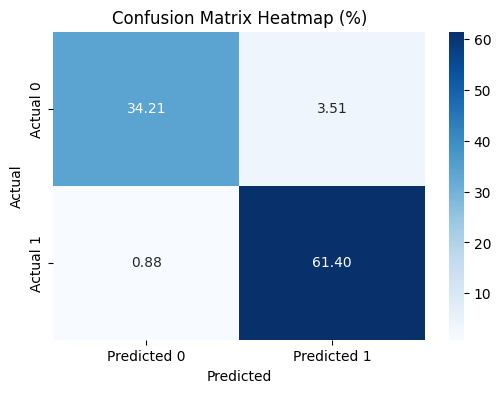

In [26]:
# OPTIONAL Now I want to see some more details about the performance metrics

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix (counts)
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n {cm}")

# Print classification report
print("\n\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# Normalize confusion matrix to percentages
cm_percent = cm.astype('float') / cm.sum() * 100

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap (%)')
plt.show()
